In [1]:
import gzip
import pandas as pd
from collections import defaultdict

ibd_path = "lwk.refined_ibd.ibd.gz"
map_path = "lwk.sorted.map"

In [2]:
# 1. chromosome lengths (max bp per chr from map)
m = pd.read_csv(map_path, sep=r"\s+", header=None, names=["CHR","MARKER","CM","BP"])
chr_maxbp = m.groupby("CHR")["BP"].max().to_dict()
total_autosomal_bp = sum(chr_maxbp[c] for c in chr_maxbp if 1 <= int(c) <= 22)

def merge_intervals(intervals):
    """intervals: list of (start,end), returns merged list"""
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = [list(intervals[0])]
    for s,e in intervals[1:]:
        if s <= merged[-1][1] + 1:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s,e])
    return merged

In [3]:
# 2. collect intervals per pair per chr
pair_chr_intervals = defaultdict(lambda: defaultdict(list))
pair_seg_lens = defaultdict(list)

with gzip.open(ibd_path, "rt") as f:
    for line in f:
        if not line.strip(): 
            continue
        id1, h1, id2, h2, chrom, start, end, lod, extra = line.split()
        iid1 = id1.split("_")[0]
        iid2 = id2.split("_")[0]
        a, b = sorted([iid1, iid2])
        chrom = int(chrom)
        if chrom < 1 or chrom > 22:
            continue
        s = int(start); e = int(end)
        if e < s:
            s, e = e, s
        pair_chr_intervals[(a,b)][chrom].append((s,e))
        pair_seg_lens[(a,b)].append(e - s + 1)

In [4]:
# 3. summarize per pair
rows = []
for (a,b), chr_dict in pair_chr_intervals.items():
    covered_bp = 0
    for chrom, intervals in chr_dict.items():
        merged = merge_intervals(intervals)
        covered_bp += sum(e - s + 1 for s,e in merged)
    segs = pair_seg_lens[(a,b)]
    rows.append({
        "A": a,
        "B": b,
        "coverage": covered_bp / total_autosomal_bp,
        "nseg": len(segs),
        "mean_seg_mb": (sum(segs)/len(segs))/1e6 if segs else 0.0,
        "max_seg_mb": (max(segs))/1e6 if segs else 0.0,
    })

cov = pd.DataFrame(rows).sort_values("coverage", ascending=False)
cov.head(30)

,A,B,coverage,nseg,mean_seg_mb,max_seg_mb
181,NA19443,NA19470,0.500244,550,3.855191,39.118603
135,NA19396,NA19397,0.489942,552,3.652877,38.260881
230,NA19331,NA19334,0.485946,548,3.777091,53.108218
371,NA19347,NA19352,0.473727,615,3.303232,28.765135
8,NA19434,NA19444,0.468737,574,3.298814,36.859689
344,NA19381,NA19382,0.456400,649,2.050206,25.347265
226,NA19445,NA19453,0.442453,623,2.094619,19.280255
137,NA19373,NA19374,0.438786,469,4.256629,49.843789
425,NA19313,NA19331,0.429646,589,2.139279,26.330644
189,NA19469,NA19470,0.413735,597,2.009257,18.619031


In [5]:
parent_child = cov[cov["coverage"] > 0.85][["A","B","coverage","nseg","max_seg_mb"]]
siblings = cov[(cov["coverage"] > 0.35) & (cov["coverage"] < 0.75)][["A","B","coverage","nseg","max_seg_mb"]]

In [6]:
parent_child

,A,B,coverage,nseg,max_seg_mb


In [7]:
siblings

,A,B,coverage,nseg,max_seg_mb
181,NA19443,NA19470,0.500244,550,39.118603
135,NA19396,NA19397,0.489942,552,38.260881
230,NA19331,NA19334,0.485946,548,53.108218
371,NA19347,NA19352,0.473727,615,28.765135
8,NA19434,NA19444,0.468737,574,36.859689
344,NA19381,NA19382,0.456400,649,25.347265
226,NA19445,NA19453,0.442453,623,19.280255
137,NA19373,NA19374,0.438786,469,49.843789
425,NA19313,NA19331,0.429646,589,26.330644
189,NA19469,NA19470,0.413735,597,18.619031


In [8]:
# PS2 Q3.3 results (siblings)

q3_3_sibling_pairs = []
q3_3_sibling_pairs.append(["NA19331", "NA19334"])
q3_3_sibling_pairs.append(["NA19347", "NA19352"])
q3_3_sibling_pairs.append(["NA19373", "NA19374"])
q3_3_sibling_pairs.append(["NA19396", "NA19397"])
q3_3_sibling_pairs.append(["NA19434", "NA19444"])
q3_3_sibling_pairs.append(["NA19443", "NA19470"])

q3_3_sibling_pairs

[['NA19331', 'NA19334'],
 ['NA19347', 'NA19352'],
 ['NA19373', 'NA19374'],
 ['NA19396', 'NA19397'],
 ['NA19434', 'NA19444'],
 ['NA19443', 'NA19470']]

In [ ]:
# Visualizations

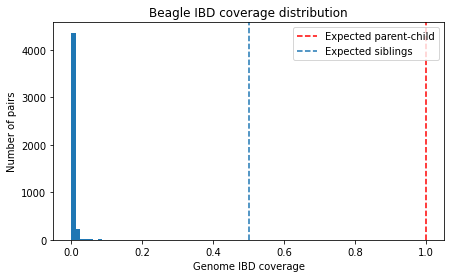

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(cov["coverage"], bins=40)

plt.axvline(1.0, linestyle="--", color="red", label="Expected parent-child")
plt.axvline(0.5, linestyle="--", label="Expected siblings")

plt.xlabel("Genome IBD coverage")
plt.ylabel("Number of pairs")
plt.title("Beagle IBD coverage distribution")
plt.legend()

plt.show()

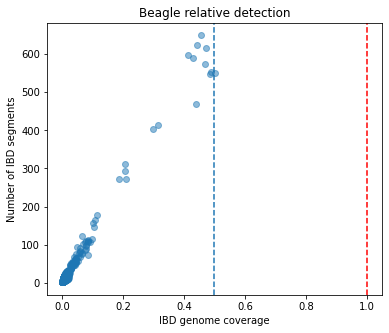

In [10]:
plt.figure(figsize=(6,5))

plt.scatter(cov["coverage"], cov["nseg"], alpha=0.5)

plt.axvline(1.0, linestyle="--", color="red")
plt.axvline(0.5, linestyle="--")

plt.xlabel("IBD genome coverage")
plt.ylabel("Number of IBD segments")
plt.title("Beagle relative detection")

plt.show()

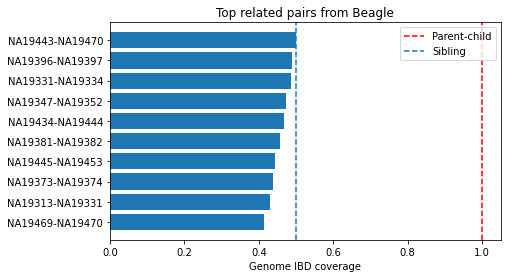

In [11]:
top = cov.sort_values("coverage", ascending=False).head(10)

plt.figure(figsize=(7,4))
plt.barh(top["A"]+"-"+top["B"], top["coverage"])

plt.axvline(1.0, linestyle="--", color="red", label="Parent-child")
plt.axvline(0.5, linestyle="--", label="Sibling")

plt.xlabel("Genome IBD coverage")
plt.title("Top related pairs from Beagle")
plt.legend()

plt.gca().invert_yaxis()
plt.show()

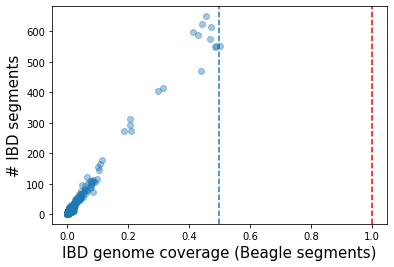

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(cov["coverage"], cov["nseg"], alpha=0.4)
ax.set_xlabel("IBD genome coverage (Beagle segments)", size=15)
ax.set_ylabel("# IBD segments", size=15)
ax.axvline(1.0, linestyle="--", color="red")  # expected parent-child
ax.axvline(0.5, linestyle="--")  # expected siblings
plt.show()